In [ ]:
# Name: Rahma Mohamed Ado Mohamed Elsharkawy 
# Email: rahma.elsharkawy82005@gmail.com

In [23]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from math import ceil, floor, sqrt, log2, pi

In [25]:
# Problem definition
N = 12                 
target = [3, 7, 8]     
n = (ceil(log2(N))) 

def grover_oracle(targets, n):
    oracle = QuantumCircuit(n)
    for t in targets:
        bin_str = format(t, f'0{n}b')
        qc = QuantumCircuit(n)
        for i, bit in enumerate(bin_str[::-1]):
            if bit == '0':
                qc.x(i)
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)  
        qc.h(n-1)
        for i, bit in enumerate(bin_str[::-1]):
            if bit == '0':
                qc.x(i)
        oracle.compose(qc, inplace=True)
    return oracle

In [27]:
def diffusion_operator(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

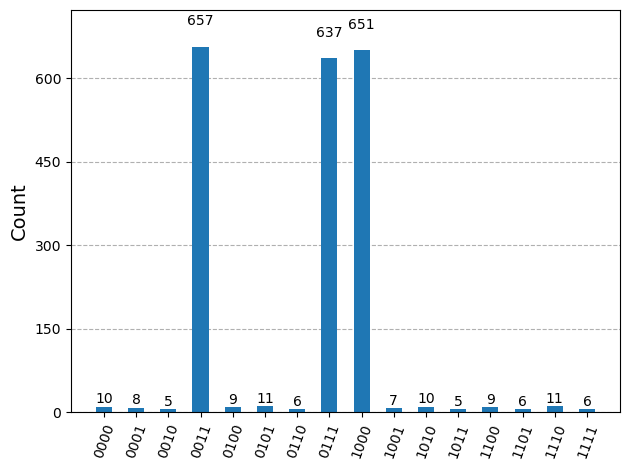

In [29]:
input_reg = QuantumRegister(n, name="q")
output_reg = ClassicalRegister(n, name="c")
qc = QuantumCircuit(input_reg, output_reg)

qc.h(input_reg)

oracle = grover_oracle(target, n)
diffuser = diffusion_operator(n)


iterations = int(floor(pi/4*sqrt(N/len(target))))

for _ in range(iterations):
    qc.compose(oracle, inplace=True)
    qc.compose(diffuser, inplace=True)

qc.measure(input_reg, output_reg)


sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=2048).result()
counts = result.get_counts()

plot_histogram(counts)